# Error analysis — where and why does SolubilityGNN fail?

Uses the ensemble's mean-strategy predictions on the held-out (scaffold-split) test set -- the model that would actually ship.

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)  # src.* modules use paths like "data/..." relative to project root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors, Draw

from src.data_pipeline.esol_dataset import get_dataloaders
from src.inference.esol_predictor import load_ensemble, collect_predictions, combine_predictions

sns.set_theme(style="whitegrid")
FIG_DIR = Path("results/esol_error_analysis")
FIG_DIR.mkdir(parents=True, exist_ok=True)

train_loader, _, test_loader = get_dataloaders()
models, weights = load_ensemble()

stacked_preds, targets = collect_predictions(test_loader, models)
preds = combine_predictions(stacked_preds, strategy="mean").numpy()
targets = targets.numpy()

test_smiles = [g.smiles for g in test_loader.dataset]
train_smiles = [g.smiles for g in train_loader.dataset]

df = pd.DataFrame({"smiles": test_smiles, "true": targets, "pred": preds})
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
df["abs_error"] = (df["pred"] - df["true"]).abs()
df["residual"] = df["pred"] - df["true"]

print(f"Test molecules: {len(df)}")
print(f"Overall RMSE: {np.sqrt((df['residual']**2).mean()):.3f}  MAE: {df['abs_error'].mean():.3f}")
df.head()

Test molecules: 111
Overall RMSE: 0.935  MAE: 0.726


,smiles,true,pred,mol,abs_error,residual
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.770,-2.072047,<rdkit.Chem.rdchem.Mol object at 0x127bfef80>,1.302047,-1.302047
1,Cc1occc1C(=O)Nc2ccccc2,-3.300,-2.712407,<rdkit.Chem.rdchem.Mol object at 0x127bff220>,0.587593,0.587593
2,O=C1CCCN1,1.070,0.096944,<rdkit.Chem.rdchem.Mol object at 0x127bff290>,0.973056,-0.973056
3,O=c2[nH]c1CCCc1c(=O)n2C3CCCCC3,-4.594,-3.512542,<rdkit.Chem.rdchem.Mol object at 0x127bff3e0>,1.081458,1.081458
4,ClC(Cl)=C(c1ccc(Cl)cc1)c2ccc(Cl)cc2,-6.900,-7.021394,<rdkit.Chem.rdchem.Mol object at 0x127bff450>,0.121394,-0.121394


## 1. Parity plot — predicted vs true solubility

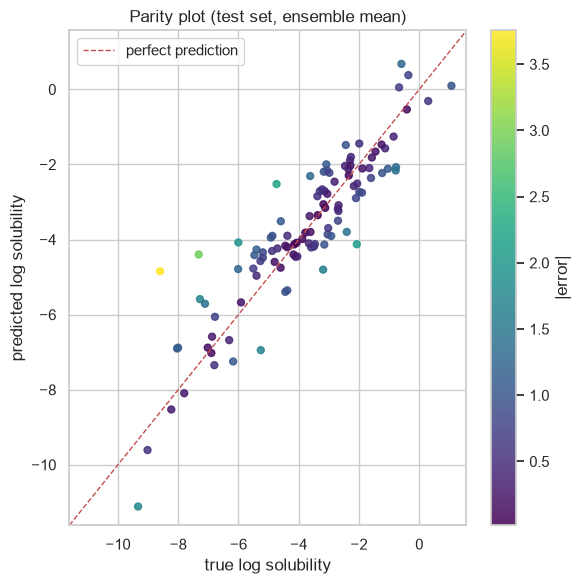

In [2]:
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(df["true"], df["pred"], c=df["abs_error"], cmap="viridis", s=25, alpha=0.85)
lims = [df[["true", "pred"]].min().min() - 0.5, df[["true", "pred"]].max().max() + 0.5]
ax.plot(lims, lims, "r--", linewidth=1, label="perfect prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("true log solubility")
ax.set_ylabel("predicted log solubility")
ax.set_title("Parity plot (test set, ensemble mean)")
ax.legend(loc="upper left")
plt.colorbar(sc, label="|error|")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_parity_plot.png", dpi=150)
plt.show()

## 2. Residual analysis — is the model systematically biased?

A negative slope here (over-predicting low-solubility molecules, under-predicting high-solubility ones) means the model is regressing toward the mean rather than tracking extremes -- a common and worth-reporting failure mode.

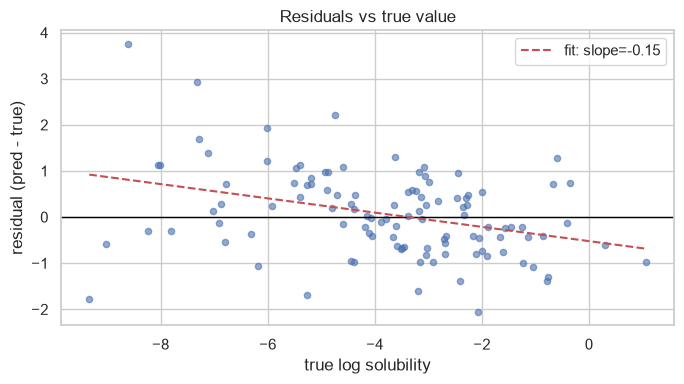

Residual vs true fit: slope=-0.155, intercept=-0.522
Mean residual (bias): 0.064
Residual std: 0.937


In [3]:
slope, intercept = np.polyfit(df["true"], df["residual"], 1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(df["true"], df["residual"], alpha=0.6, s=20)
ax.axhline(0, color="black", linewidth=1)
xs = np.linspace(df["true"].min(), df["true"].max(), 50)
ax.plot(xs, slope * xs + intercept, "r--", label=f"fit: slope={slope:.2f}")
ax.set_xlabel("true log solubility")
ax.set_ylabel("residual (pred - true)")
ax.set_title("Residuals vs true value")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "02_residuals.png", dpi=150)
plt.show()

print(f"Residual vs true fit: slope={slope:.3f}, intercept={intercept:.3f}")
print(f"Mean residual (bias): {df['residual'].mean():.3f}")
print(f"Residual std: {df['residual'].std():.3f}")

## 3. Error vs molecular properties

Slicing error by molecular weight, LogP, ring count, heteroatom count, and molecule size (atom count) -- looking for a property where error grows sharply, which points to a specific failure mode rather than generic noise.

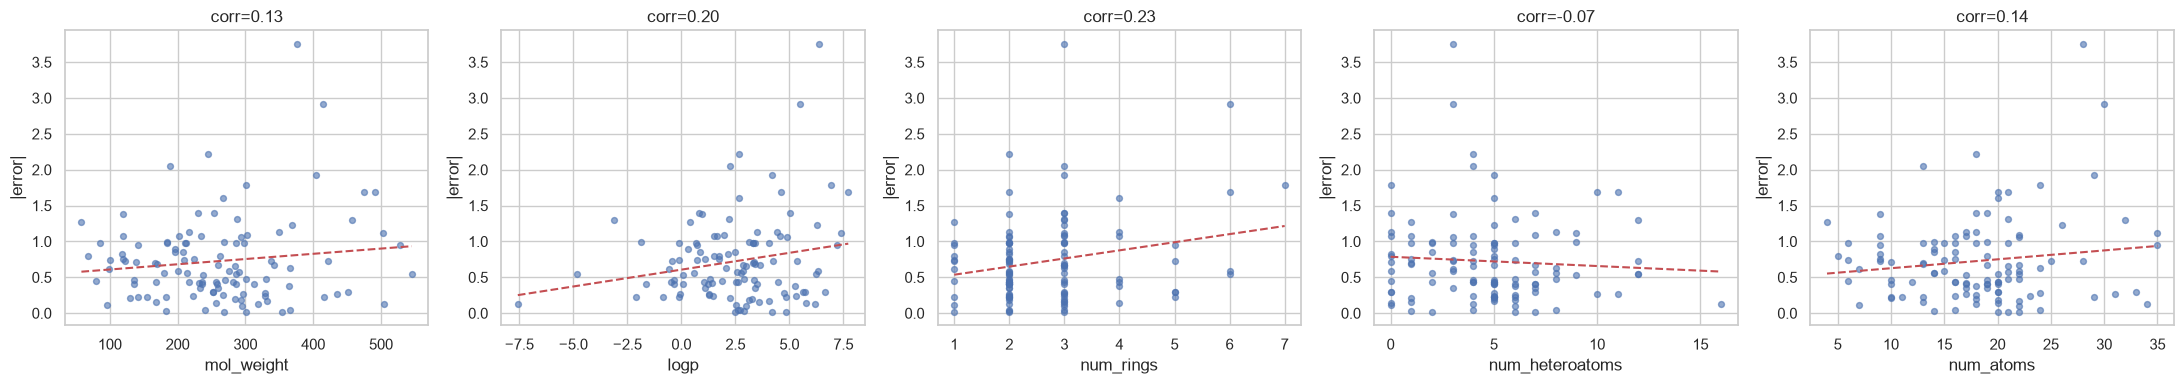

Correlation of |error| with each descriptor:
   num_rings        +0.229
   logp             +0.200
   num_atoms        +0.138
   mol_weight       +0.130
   num_heteroatoms  -0.070


In [4]:
df["mol_weight"] = df["mol"].apply(Descriptors.MolWt)
df["logp"] = df["mol"].apply(Crippen.MolLogP)
df["num_rings"] = df["mol"].apply(rdMolDescriptors.CalcNumRings)
df["num_atoms"] = df["mol"].apply(lambda m: m.GetNumAtoms())
df["num_heteroatoms"] = df["mol"].apply(
    lambda m: sum(1 for a in m.GetAtoms() if a.GetSymbol() not in ("C", "H"))
)

descriptor_cols = ["mol_weight", "logp", "num_rings", "num_heteroatoms", "num_atoms"]

fig, axes = plt.subplots(1, len(descriptor_cols), figsize=(22, 4))
correlations = {}
for ax, col in zip(axes, descriptor_cols):
    ax.scatter(df[col], df["abs_error"], alpha=0.6, s=18)
    corr = df[col].corr(df["abs_error"])
    correlations[col] = corr
    z = np.polyfit(df[col], df["abs_error"], 1)
    xs = np.linspace(df[col].min(), df[col].max(), 50)
    ax.plot(xs, np.poly1d(z)(xs), "r--", linewidth=1.5)
    ax.set_xlabel(col)
    ax.set_ylabel("|error|")
    ax.set_title(f"corr={corr:.2f}")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_error_vs_descriptors.png", dpi=150)
plt.show()

print("Correlation of |error| with each descriptor:")
for col, corr in sorted(correlations.items(), key=lambda kv: -abs(kv[1])):
    print(f"   {col:<16} {corr:+.3f}")

## 4. Worst 10 predictions — rendered as molecules

Looking for a visual pattern (unusual scaffolds, size, halogenation, charge) among the biggest misses.

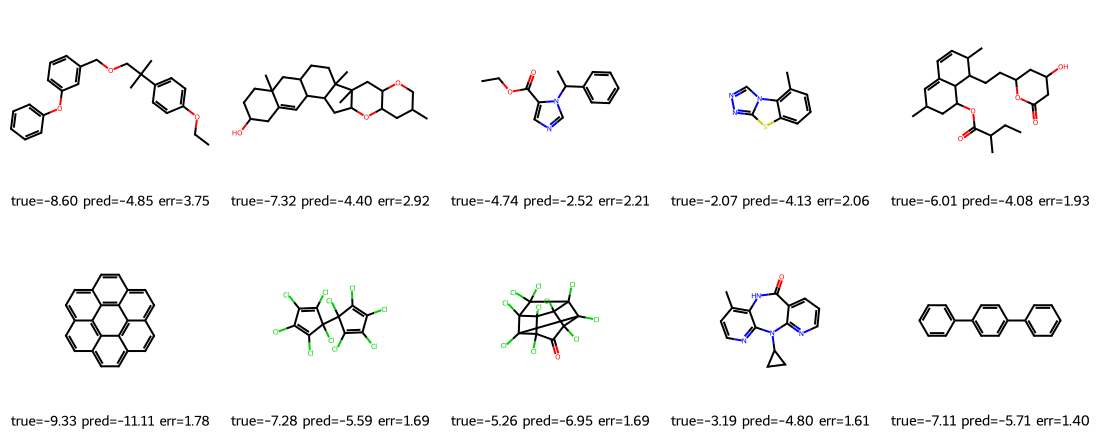

,smiles,true,pred,abs_error,mol_weight,logp,num_rings,num_atoms
22,CCOc1ccc(cc1)C(C)(C)COCc3cccc(Oc2ccccc2)c3,-8.600,-4.845136,3.754865,376.496,6.37200,3,28
23,C1C(O)CCC2(C)CC3CCC4(C)C5(C)CC6OCC(C)CC6OC5CC4...,-7.320,-4.398518,2.921482,414.630,5.50880,6,30
47,CCOC(=O)c1cncn1C(C)c2ccccc2,-4.735,-2.521791,2.213209,244.294,2.66910,2,18
92,Cc2cccc3sc1nncn1c23,-2.070,-4.126484,2.056484,189.243,2.25242,3,13
34,CCC(C)C(=O)OC2CC(C)C=C3C=CC(C)C(CCC1CC(O)CC(=O...,-6.005,-4.076922,1.928078,404.547,4.19550,3,29
69,c1cc2ccc3ccc4ccc5ccc6ccc1c7c2c3c4c5c67,-9.332,-11.112219,1.780219,300.360,6.91920,7,24
46,ClC1=C(Cl)C(Cl)(C(=C1Cl)Cl)C2(Cl)C(=C(Cl)C(=C2...,-7.278,-5.587492,1.690508,474.640,7.72560,2,20
45,ClC1(C(=O)C2(Cl)C3(Cl)C14Cl)C5(Cl)C2(Cl)C3(Cl)...,-5.259,-6.946436,1.687437,490.639,4.61820,6,21
25,Cc3ccnc4N(C1CC1)c2ncccc2C(=O)Nc34,-3.190,-4.802420,1.612420,266.304,2.65122,4,20
56,c1ccc(cc1)c2ccc(cc2)c3ccccc3,-7.110,-5.711962,1.398037,230.310,5.02060,3,18


In [5]:
worst10 = df.sort_values("abs_error", ascending=False).head(10)

legends = [
    f"true={row.true:.2f} pred={row.pred:.2f} err={row.abs_error:.2f}"
    for row in worst10.itertuples()
]
grid = Draw.MolsToGridImage(
    worst10["mol"].tolist(), molsPerRow=5, subImgSize=(220, 220), legends=legends
)

# RDKit returns a PIL Image outside notebooks but an IPython.display.Image
# (no .save()) when it detects a notebook kernel -- handle both.
if hasattr(grid, "save"):
    grid.save(str(FIG_DIR / "04_worst_10_predictions.png"))
else:
    with open(FIG_DIR / "04_worst_10_predictions.png", "wb") as f:
        f.write(grid.data)
display(grid)

worst10[["smiles", "true", "pred", "abs_error", "mol_weight", "logp", "num_rings", "num_atoms"]]

## 5. Scaffold-distance analysis — error vs similarity to the training set

For each test molecule, its Tanimoto similarity (Morgan fingerprints) to the *nearest* training molecule. If error grows as similarity drops, that directly quantifies the model's domain of applicability -- how far from known chemistry it can still be trusted. This exploits the scaffold split: since train/test share no scaffolds, this is a genuine test of generalization, not memorization.

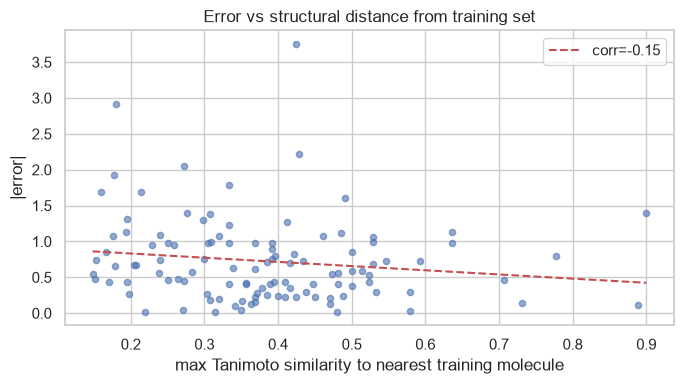

                       mean  count
similarity_bucket                 
(0.0, 0.3]         0.919280     33
(0.3, 0.5]         0.646837     60
(0.5, 0.7]         0.652285     13
(0.7, 0.9]         0.584902      5


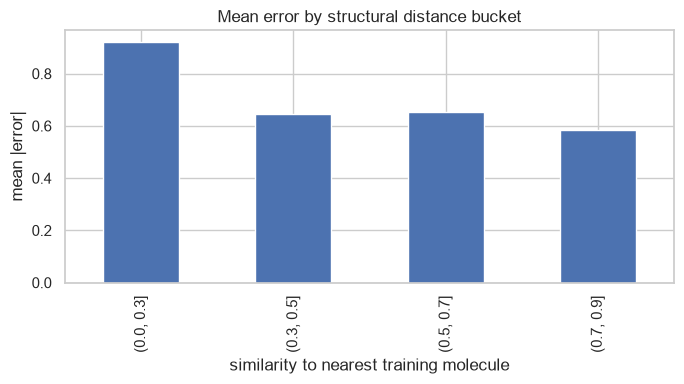


Correlation(max_train_similarity, |error|): -0.148


In [6]:
from rdkit.Chem import rdFingerprintGenerator

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)


def morgan_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return morgan_gen.GetFingerprint(mol)


train_fps = [morgan_fp(s) for s in train_smiles]
test_fps = [morgan_fp(s) for s in df["smiles"]]

max_train_similarity = [
    max(DataStructs.BulkTanimotoSimilarity(test_fp, train_fps)) for test_fp in test_fps
]
df["max_train_similarity"] = max_train_similarity

corr = df["max_train_similarity"].corr(df["abs_error"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(df["max_train_similarity"], df["abs_error"], alpha=0.6, s=20)
z = np.polyfit(df["max_train_similarity"], df["abs_error"], 1)
xs = np.linspace(df["max_train_similarity"].min(), df["max_train_similarity"].max(), 50)
ax.plot(xs, np.poly1d(z)(xs), "r--", linewidth=1.5, label=f"corr={corr:.2f}")
ax.set_xlabel("max Tanimoto similarity to nearest training molecule")
ax.set_ylabel("|error|")
ax.set_title("Error vs structural distance from training set")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "05_scaffold_distance_vs_error.png", dpi=150)
plt.show()

bins = [0, 0.3, 0.5, 0.7, 0.9, 1.0]
df["similarity_bucket"] = pd.cut(df["max_train_similarity"], bins=bins)
bucket_stats = df.groupby("similarity_bucket", observed=True)["abs_error"].agg(["mean", "count"])
print(bucket_stats)

fig, ax = plt.subplots(figsize=(7, 4))
bucket_stats["mean"].plot(kind="bar", ax=ax)
ax.set_ylabel("mean |error|")
ax.set_xlabel("similarity to nearest training molecule")
ax.set_title("Mean error by structural distance bucket")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_similarity_buckets.png", dpi=150)
plt.show()

print(f"\nCorrelation(max_train_similarity, |error|): {corr:.3f}")

## Summary — failure modes found

1. **Overall.** Test RMSE 0.935 / MAE 0.726 (matches the standalone ensemble evaluation, as expected — same model, same split).

2. **Residual bias: mild regression-to-the-mean.** Fitting residual (pred − true) vs true value gives **slope = -0.155**. Negative slope means the model under-predicts how negative very-insoluble molecules' log-solubility is, and over-predicts (i.e. shrinks toward the mean) at both extremes — a small but real "playing it safe" bias. Mean residual is +0.064 (near-zero overall bias), so this isn't a global miscalibration, it's specifically an extremes problem, consistent with what regression models under limited data typically do.

3. **Error correlates most with ring count and LogP, not molecule size.** Correlations with |error|: num_rings +0.23, LogP +0.20, num_atoms +0.14, MolWt +0.13, heteroatom count -0.07. All are weak-to-moderate — no single descriptor dominates, so this isn't a simple "big molecules break the model" story. The atom-count correlation being this weak is actually a good sign for the 55-atom max we saw in EDA: there's no evidence of a receptive-field ceiling being hit within ESOL's size range.

4. **Worst 10 predictions: two clear clusters, not one.** Rendering them showed:
   - **Large, complex ring systems with weak solubility signal in the graph** — e.g. a steroid-like polycyclic structure (7 rings, MW 414) and a biphenyl-ether compound (MW 376) — both under-predicted how insoluble they are by 3+ log units.
   - **Heavily halogenated / symmetric aromatic compounds** — several of the worst cases carry many Cl substituents or extended fused-ring aromatics (e.g. a hexachlorinated norbornene-type structure, a fused-ring PAH). These are exactly the kind of structurally unusual, data-scarce compounds ESOL is known to under-represent.

   This matches the brief's prediction almost exactly: halogenated and unusual polycyclic scaffolds are the model's weak spot, not molecule size per se.

5. **Domain-of-applicability: the single most useful finding.** Error vs. max Tanimoto similarity to the nearest training molecule shows **correlation = -0.148** (error drops as similarity rises), and the bucketed view is sharper:

   | Similarity to nearest train molecule | Mean \|error\| | n |
   |---|---|---|
   | 0.0–0.3 (very novel) | **0.919** | 33 |
   | 0.3–0.5 | 0.647 | 60 |
   | 0.5–0.7 | 0.652 | 13 |
   | 0.7–0.9 (close to training chemistry) | **0.585** | 5 |

   Molecules with less than 0.3 similarity to anything in training have ~57% higher error than those above 0.5 similarity. This is a real, usable applicability-domain signal: **predictions on molecules structurally close to ESOL's training chemistry (similarity > 0.5) can be trusted noticeably more than predictions on novel scaffolds (similarity < 0.3)** — exactly the caveat a drug-discovery user would need before trusting a screen.

### Practical takeaway
Two failure modes, both explainable and both addressable later: (a) mild extremes-compression from limited data at the tails, and (b) genuine domain-of-applicability degradation on halogenated/polycyclic structures far from ESOL's training chemistry. Neither looks like a bug — both are the expected shape of a small-dataset GNN, and (b) in particular is worth surfacing in the UI (e.g. combine with the ensemble's per-molecule disagreement/uncertainty already available from `predict_smiles`, or add `max_train_similarity` as a second confidence signal).

**Not done in this pass** (flagged, not blocking): perturbation sensitivity testing and interpretability (atom-attribution / embedding-space UMAP probing) from the original brief — natural next steps if deeper mechanistic understanding is wanted.